In [24]:
import joblib

data = joblib.load('processed_data.pkl')
X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(273881, 45)
(118566, 45)
(273881,)
(118566,)


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_recall_curve,average_precision_score,roc_auc_score,classification_report,roc_curve)
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd


In [27]:
def print_score(true, pred, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")
        
    elif train==False:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Test Result:\n================================================")        
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")

##### XGBoost Classifier

In [30]:
# Calculate class weight majority/minority
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("Scale Pos Weight:", scale_pos_weight)

# XGBoost classifier
xgb_clf = XGBClassifier(
    eval_metric='aucpr',
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1
)

# Hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Randomized hyperparameter tuning
xgb_cv = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train
xgb_cv.fit(X_train, y_train)

# Use the best already-fitted model
xgb_clf = xgb_cv.best_estimator_

print("\nBest Parameters:")
print(xgb_cv.best_params_)

print(
    f"\nBest CV PR-AUC: "
    f"{xgb_cv.best_score_:.4f}"
)

Scale Pos Weight: 4.0802433640629925
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV PR-AUC: 0.7816


In [31]:
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

print_score(y_train, y_train_pred, train=True)
print_score(y_test, y_test_pred, train=False)

Train Result:
Accuracy Score: 82.47%
_______________________________________________
CLASSIFICATION REPORT:
                       0             1  accuracy      macro avg   weighted avg
precision       0.953068      0.535150  0.824745       0.744109       0.870805
recall          0.822285      0.834783  0.824745       0.828534       0.824745
f1-score        0.882859      0.652199  0.824745       0.767529       0.837456
support    219970.000000  53911.000000  0.824745  273881.000000  273881.000000
_______________________________________________
Confusion Matrix: 
 [[180878  39092]
 [  8907  45004]]

Test Result:
Accuracy Score: 81.01%
_______________________________________________
CLASSIFICATION REPORT:
                      0             1  accuracy      macro avg   weighted avg
precision      0.943289      0.509475  0.810064       0.726382       0.858368
recall         0.812691      0.799268  0.810064       0.805979       0.810064
f1-score       0.873134      0.622287  0.810064     

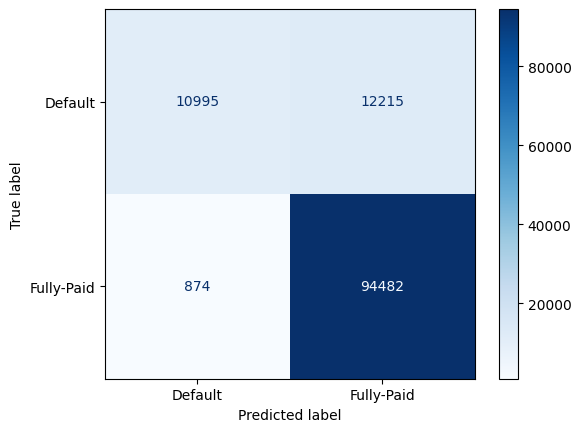

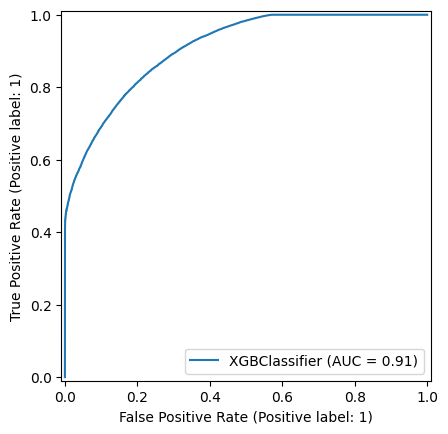

In [7]:
disp = ConfusionMatrixDisplay.from_estimator(
    xgb_clf, X_test, y_test, 
    cmap='Blues', values_format='d', 
    display_labels=['Default', 'Fully-Paid']
)

disp = RocCurveDisplay.from_estimator(xgb_clf, X_test, y_test)

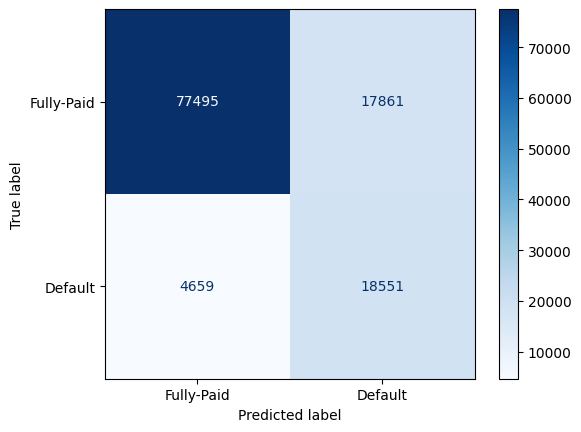

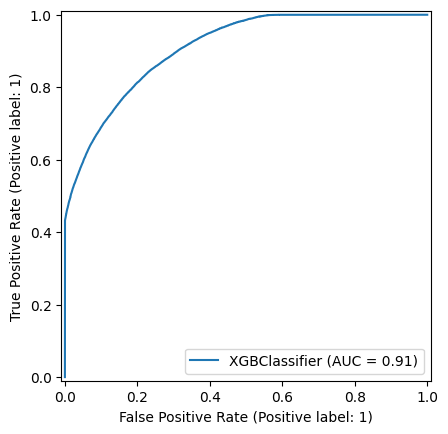

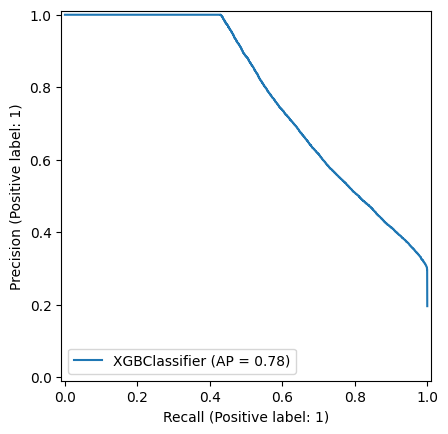

In [38]:
from sklearn.metrics import PrecisionRecallDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    xgb_clf,
    X_test,
    y_test,
    cmap='Blues',
    values_format='d',
    display_labels=['Fully-Paid', 'Default']
)

disp = RocCurveDisplay.from_estimator(
    xgb_clf,
    X_test,
    y_test
)

disp = PrecisionRecallDisplay.from_estimator(
    xgb_clf,
    X_test,
    y_test
)

In [33]:
scores_dict={}
scores_dict['XGBoost'] = {
        'Train': roc_auc_score(y_train, xgb_clf.predict_proba(X_train)[:, 1]),
        'Test': roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1]),
    }

#### Random Forest Classifier

In [34]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

rf_cv = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=2
    ),
    param_distributions=param_grid_rf,
    cv=3,
    n_iter=15,
    scoring='average_precision',
    n_jobs=2,
    random_state=42,
    verbose=1
)

rf_cv.fit(X_train, y_train)

rf_clf = rf_cv.best_estimator_

print("Best Parameters:")
print(rf_cv.best_params_)

print(f"Best CV PR-AUC: {rf_cv.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 16, 'class_weight': 'balanced'}
Best CV PR-AUC: 0.7622


In [35]:
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

print_score(y_train, y_train_pred, train=True)
print_score(y_test, y_test_pred, train=False)

Train Result:
Accuracy Score: 82.64%
_______________________________________________
CLASSIFICATION REPORT:
                       0             1  accuracy      macro avg   weighted avg
precision       0.946303      0.539363  0.826363       0.742833       0.866201
recall          0.830959      0.807609  0.826363       0.819284       0.826363
f1-score        0.884888      0.646776  0.826363       0.765832       0.838018
support    219970.000000  53911.000000  0.826363  273881.000000  273881.000000
_______________________________________________
Confusion Matrix: 
 [[182786  37184]
 [ 10372  43539]]

Test Result:
Accuracy Score: 80.61%
_______________________________________________
CLASSIFICATION REPORT:
                      0             1  accuracy      macro avg   weighted avg
precision      0.933820      0.503171  0.806125       0.718496       0.849518
recall         0.816823      0.762171  0.806125       0.789497       0.806125
f1-score       0.871412      0.606164  0.806125     

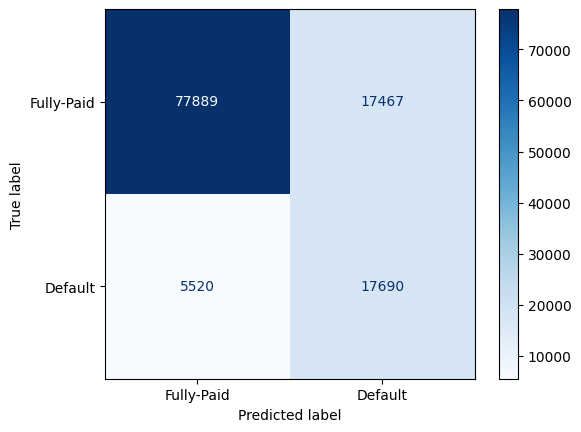

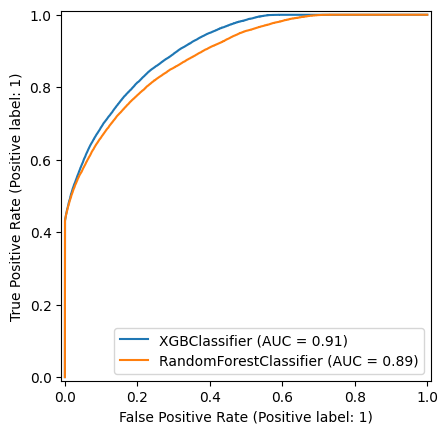

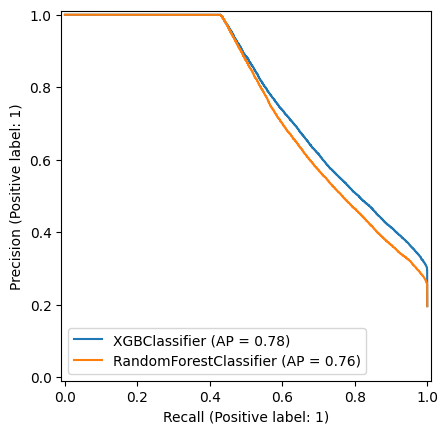

In [45]:
disp = ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test, 
                             cmap='Blues', values_format='d', 
                             display_labels=['Fully-Paid','Default'])

disp = RocCurveDisplay.from_estimator(xgb_clf, X_test, y_test)

RocCurveDisplay.from_estimator(rf_clf, X_test, y_test, ax=disp.ax_)

disp = PrecisionRecallDisplay.from_estimator(xgb_clf, X_test, y_test)

PrecisionRecallDisplay.from_estimator(rf_clf, X_test, y_test, ax=disp.ax_)

In [ ]:
# scores_dict={}
# scores_dict['XGBoost'] = {
#         'Train': roc_auc_score(y_train, rf_clf.predict_proba(X_train)[:, 1]),
#         'Test': roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]),
#     }

In [42]:
# print(type(rf_clf))
# print(hasattr(rf_clf, "predict_proba"))

In [46]:
ml_models = {
    'Random Forest': rf_clf, 
    'XGBoost': xgb_clf, 
}

for model in ml_models:
    print(f"{model.upper():{30}} roc_auc_score: {roc_auc_score(y_test, ml_models[model].predict_proba(X_test)[:,1]):.3f}")

RANDOM FOREST                  roc_auc_score: 0.889
XGBOOST                        roc_auc_score: 0.908


In [47]:
ml_models = {
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf,
}

for model_name, model in ml_models.items():

    y_test_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_test_proba)
    pr_auc = average_precision_score(y_test, y_test_proba)

    print(
        f"{model_name:<20} "
        f"ROC-AUC: {roc_auc:.3f} | "
        f"PR-AUC: {pr_auc:.3f}"
    )

Random Forest        ROC-AUC: 0.889 | PR-AUC: 0.762
XGBoost              ROC-AUC: 0.908 | PR-AUC: 0.783
